# Feature Engineering & Market Classification
## COM6033 - Applied Artificial Intelligence Project
### Market Trend Classification for North Yorkshire Property Market

---

## Notebook Purpose

**Objective:** Transform transaction-level data into postcode-sector features and create market trend classification labels.

**Key Transformation:**
- **Input:** 66,500+ individual transactions
- **Output:** ~1,000 postcode-sector-quarter observations with features and labels

**Feature Engineering:**
1. Aggregate transactions to postcode-sector-quarter level
2. Calculate price metrics (median, growth rates)
3. Calculate transaction volume metrics (activity levels)
4. Calculate volatility and trend indicators
5. Create classification labels based on multi-factor criteria

**Classification Categories:**
- **Booming:** Rapid growth + high activity
- **Growing:** Steady growth + moderate activity
- **Stable:** Minimal change + consistent activity
- **Declining:** Falling prices or activity

---

## Table of Contents
1. Load Cleaned Data
2. Exploration Data Aggregation Analysis
3. Create Postcode-Sector-Quarter Aggregations
4. Calculate Price Features
5. Calculate Volume Features
6. Calculate Derived Features
7. Create Classification Labels
8. Final Dataset Preparation
9. Save ML-Ready Data
10. Summary & Insights

---

## 1. Load Cleaned Data

**What we're doing:** Loading the cleaned transaction data from the previous notebook.

**Why this matters:**
- Start with validated, quality-controlled data
- Understand the starting point for aggregation
- Verify data integrity

**Expected:** ~66,500 transactions across ~200 postcode sectors

---

In [231]:
# DATA LOADING

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Load cleaned data
df = pd.read_csv('../data/processed/north_yorkshire_2019_2023_clean.csv')

# Convert date to datetime
df['date_transfer'] = pd.to_datetime(df['date_transfer'])

# Recreate temporal features if needed
df['year'] = df['date_transfer'].dt.year
df['quarter'] = df['date_transfer'].dt.quarter
df['year_quarter'] = df['date_transfer'].dt.to_period('Q')

print(f"\nCleaned data loaded")
print(f"Transactions: {len(df):,}")
print(f"Date Range: {df['date_transfer'].min().date()} to {df['date_transfer'].max().date()}")
print(f"Postcode Sectors: {df['postcode_sector'].nunique()}")
print(f"Time Periods: {df['year_quarter'].nunique()} quarters")



Cleaned data loaded
Transactions: 66,406
Date Range: 2019-01-02 to 2023-12-31
Postcode Sectors: 52
Time Periods: 20 quarters


## 2. Exploratory Aggregation Analysis

**What we're doing:** Understanding our data distribution before aggregation.

**Why this matters:**
- See how much data we have per sector per quarter
- Identify potential issues (sectors with very sparse data)
- Decide on aggregation strategy

**Key Questions:**
- How many transactions per sector per quarter (on average)?
- Are some sectors/quarters too sparse?
- Should we aggregate by quarter or year?

---

In [232]:
# AGGREGATION FEASIBILITY ANALYSIS

# Count transactions per sector-quarter combination
sector_quarter_counts = df.groupby(['postcode_sector', 'year_quarter']).size()

print(f"\nSector-Quarter Statistics:")
print(f"Total sector-quarter combinations: {len(sector_quarter_counts):,}")
print(f"Min transactions per combo: {sector_quarter_counts.min()}")
print(f"Max transactions per combo: {sector_quarter_counts.max()}")
print(f"Mean transactions per combo: {sector_quarter_counts.mean():.1f}")
print(f"Median transactions per combo: {sector_quarter_counts.median():.0f}")

# Distribution of transaction counts
print(f"\nDistribution of Transactions per Sector-Quarter:")
bins = [0, 1, 2, 5, 10, 20, 50, 100, sector_quarter_counts.max()]
labels = ['1', '2', '3-5', '6-10', '11-20', '21-50', '51-100', '100+']
distribution = pd.cut(sector_quarter_counts, bins=bins, labels=labels).value_counts().sort_index()

for label, count in distribution.items():
    pct = count / len(sector_quarter_counts) * 100
    print(f"{label:>6s} transactions: {count:4,} combinations ({pct:5.1f}%)")

# Check for very sparse combinations
sparse_threshold = 3
sparse_combos = sector_quarter_counts[sector_quarter_counts < sparse_threshold]
print(f"\nCombinations with < {sparse_threshold} transactions: {len(sparse_combos):,} ({len(sparse_combos)/len(sector_quarter_counts)*100:.1f}%)")

print(f"\nQuarterly aggregation is feasible")
print(f"Sufficient data per sector-quarter for trend analysis")


Sector-Quarter Statistics:
Total sector-quarter combinations: 1,019
Min transactions per combo: 1
Max transactions per combo: 368
Mean transactions per combo: 65.2
Median transactions per combo: 47

Distribution of Transactions per Sector-Quarter:
     1 transactions:   42 combinations (  4.1%)
     2 transactions:   36 combinations (  3.5%)
   3-5 transactions:   68 combinations (  6.7%)
  6-10 transactions:   85 combinations (  8.3%)
 11-20 transactions:  121 combinations ( 11.9%)
 21-50 transactions:  183 combinations ( 18.0%)
51-100 transactions:  264 combinations ( 25.9%)
  100+ transactions:  220 combinations ( 21.6%)

Combinations with < 3 transactions: 78 (7.7%)

Quarterly aggregation is feasible
Sufficient data per sector-quarter for trend analysis


## 3. Create Postcode-Sector-Quarter Aggregations

**What we're doing:** Aggregating individual transactions to postcode-sector-quarter level.

**Why this matters:**
- This is our unit of analysis for classification
- Each row represents a sector's performance in a specific quarter
- Enables temporal comparison (quarter-over-quarter, year-over-year)

**Aggregation Strategy:**
- **Group by:** postcode_sector + year_quarter
- **Calculate:** Count, median price, mean price, price std, property type mix
- **Result:** One row per sector per quarter

**Example Transformation:**
```
BEFORE: 50 transactions in HG1, Q1 2020
AFTER:  1 row with aggregated metrics for HG1, Q1 2020
```

---

In [233]:
# SECTOR-QUARTER AGGREGATION

# Aggregate to postcode-sector-quarter level
sector_quarter_agg = df.groupby(['postcode_sector', 'year_quarter']).agg({
    'price': ['count', 'median', 'mean', 'std', 'min', 'max'],
    'transaction_id': 'count',
    'property_type_desc': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown',
    'district': 'first',
    'town_city': 'first'
}).reset_index()

# Flatten column names
sector_quarter_agg.columns = [
    'postcode_sector', 'year_quarter',
    'transaction_count', 'median_price', 'mean_price', 'price_std', 'min_price', 'max_price',
    'transaction_count_check',
    'dominant_property_type', 'district', 'town_city'
]

# Drop duplicate count column
sector_quarter_agg = sector_quarter_agg.drop('transaction_count_check', axis=1)

# Convert year_quarter to string for easier handling
sector_quarter_agg['year_quarter'] = sector_quarter_agg['year_quarter'].astype(str)

# Extract year and quarter separately
sector_quarter_agg['year'] = sector_quarter_agg['year_quarter'].str[:4].astype(int)
sector_quarter_agg['quarter'] = sector_quarter_agg['year_quarter'].str[-1].astype(int)

print(f"\nAggregation complete!")
print(f"Input: {len(df):,} transactions")
print(f"Output: {len(sector_quarter_agg):,} sector-quarter observations")
print(f"Compression: {len(df)/len(sector_quarter_agg):.1f}x")

print(f"\nAggregated Dataset Structure:")
print(f"Unique Sectors: {sector_quarter_agg['postcode_sector'].nunique()}")
print(f"Time Periods: {sector_quarter_agg['year_quarter'].nunique()} quarters")
print(f"Years Covered: {sorted(sector_quarter_agg['year'].unique())}")

print(f"\nSample Aggregated Data:")
print(sector_quarter_agg.head(3))



Aggregation complete!
Input: 66,406 transactions
Output: 1,019 sector-quarter observations
Compression: 65.2x

Aggregated Dataset Structure:
Unique Sectors: 52
Time Periods: 20 quarters
Years Covered: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

Sample Aggregated Data:
  postcode_sector year_quarter  transaction_count  median_price  \
0            BD20       2019Q1                 81      190000.0   
1            BD20       2019Q2                 84      222000.0   
2            BD20       2019Q3                 69      240000.0   

      mean_price      price_std  min_price  max_price dominant_property_type  \
0  264903.209877  175674.518829      65000     758500               Terraced   
1  292339.952381  232735.137888      50000    1825006               Terraced   
2  267168.188406  127908.089658     123000     795000               Terraced   

  district town_city  year  quarter  
0   CRAVEN  KEIGHLEY  2019        1  
1   CRAVEN  KEIGHLEY  2019

## 4. Calculate Price Features

**What we're doing:** Creating features that capture price trends and changes.

**Why this matters:**
- Price growth is the PRIMARY indicator of market health
- Need both absolute prices and growth rates
- Year-over-year comparison removes seasonal effects

**Features to Create:**

1. **Year-over-Year Price Change (%):**
   - Compare Q1 2020 to Q1 2019 (same quarter, different year)
   - Removes seasonality, shows true trend
   - Formula: `((price_current - price_previous) / price_previous) * 100`

2. **Quarter-over-Quarter Price Change (%):**
   - Compare Q2 2020 to Q1 2020 (consecutive quarters)
   - Shows short-term momentum
   - More volatile than YoY

3. **Price Momentum:**
   - 3-quarter rolling average of price changes
   - Smooths volatility, shows sustained trends

4. **Price Volatility:**
   - Standard deviation within each quarter
   - High volatility = diverse sales, low = consistent market

---

In [234]:
# PRICE FEATURE ENGINEERING

# Sort by sector and time
sector_quarter_agg = sector_quarter_agg.sort_values(['postcode_sector', 'year', 'quarter']).reset_index(drop=True)

# 1. Year-over-Year (YoY) Price Change
print("\n1. CALCULATING YEAR-OVER-YEAR PRICE CHANGE...")

# For each sector, calculate YoY change (comparing same quarter previous year)
sector_quarter_agg['yoy_price_change_pct'] = np.nan

for sector in sector_quarter_agg['postcode_sector'].unique():
    sector_mask = sector_quarter_agg['postcode_sector'] == sector
    sector_data = sector_quarter_agg[sector_mask].copy()

    for idx, row in sector_data.iterrows():
        current_year = row['year']
        current_quarter = row['quarter']
        current_price = row['median_price']

        # Find same quarter previous year
        prev_year_data = sector_data[
            (sector_data['year'] == current_year - 1) &
            (sector_data['quarter'] == current_quarter)
        ]

        if len(prev_year_data) > 0:
            prev_price = prev_year_data['median_price'].iloc[0]
            if prev_price > 0:
                yoy_change = ((current_price - prev_price) / prev_price) * 100
                sector_quarter_agg.loc[idx, 'yoy_price_change_pct'] = yoy_change

yoy_valid = sector_quarter_agg['yoy_price_change_pct'].notna().sum()
print(f"YoY price change calculated for {yoy_valid:,} observations")
print(f"Range: {sector_quarter_agg['yoy_price_change_pct'].min():.1f}% to {sector_quarter_agg['yoy_price_change_pct'].max():.1f}%")

# 2. Quarter-over-Quarter (QoQ) Price Change
print("\n2. CALCULATING QUARTER-OVER-QUARTER PRICE CHANGE...")

sector_quarter_agg['qoq_price_change_pct'] = sector_quarter_agg.groupby('postcode_sector')['median_price'].pct_change() * 100

qoq_valid = sector_quarter_agg['qoq_price_change_pct'].notna().sum()
print(f"QoQ price change calculated for {qoq_valid:,} observations")

# 3. Price Rolling Average (3-quarter)
print("\n3. CALCULATING PRICE MOMENTUM (3-QUARTER ROLLING AVERAGE)...")

sector_quarter_agg['price_ma3'] = sector_quarter_agg.groupby('postcode_sector')['median_price'].transform(
    lambda x: x.rolling(window=3, min_periods=2).mean()
)

ma_valid = sector_quarter_agg['price_ma3'].notna().sum()
print(f"3-quarter moving average calculated for {ma_valid:,} observations")

# 4. Price Volatility Score
print("\n4. CALCULATING PRICE VOLATILITY...")

# Coefficient of variation within each sector-quarter
sector_quarter_agg['price_volatility'] = (sector_quarter_agg['price_std'] / sector_quarter_agg['mean_price']) * 100

# Handle division by zero or missing std
sector_quarter_agg['price_volatility'] = sector_quarter_agg['price_volatility'].fillna(0)

print(f"Price volatility calculated")
print(f"Mean volatility: {sector_quarter_agg['price_volatility'].mean():.1f}%")

print(f"\nPrice features complete")
print(f"Features created: yoy_price_change_pct, qoq_price_change_pct, price_ma3, price_volatility")


1. CALCULATING YEAR-OVER-YEAR PRICE CHANGE...
YoY price change calculated for 802 observations
Range: -91.1% to 336.3%

2. CALCULATING QUARTER-OVER-QUARTER PRICE CHANGE...
QoQ price change calculated for 967 observations

3. CALCULATING PRICE MOMENTUM (3-QUARTER ROLLING AVERAGE)...
3-quarter moving average calculated for 967 observations

4. CALCULATING PRICE VOLATILITY...
Price volatility calculated
Mean volatility: 53.2%

Price features complete
Features created: yoy_price_change_pct, qoq_price_change_pct, price_ma3, price_volatility


## 5. Calculate Volume Features

**What we're doing:** Creating features that capture market activity levels.

**Why this matters:**
- Transaction volume indicates market health
- High activity = hot market, low activity = slow market
- Changes in volume can predict price changes

**Features to Create:**

1. **Year-over-Year Volume Change (%):**
   - Compare transaction counts YoY
   - Shows if market is heating up or cooling down

2. **Quarter-over-Quarter Volume Change (%):**
   - Short-term activity trends

3. **Volume Momentum:**
   - Rolling average of transaction counts
   - Smooths seasonal fluctuations

4. **Market Activity Level:**
   - Categorical: High/Medium/Low based on transaction count
   - Relative to sector's historical average

---

In [235]:
# VOLUME FEATURE ENGINEERING

# 1. Year-over-Year Volume Change
print("\n1. CALCULATING YEAR-OVER-YEAR VOLUME CHANGE")

sector_quarter_agg['yoy_volume_change_pct'] = np.nan

for sector in sector_quarter_agg['postcode_sector'].unique():
    sector_mask = sector_quarter_agg['postcode_sector'] == sector
    sector_data = sector_quarter_agg[sector_mask].copy()

    for idx, row in sector_data.iterrows():
        current_year = row['year']
        current_quarter = row['quarter']
        current_volume = row['transaction_count']

        # Find same quarter previous year
        prev_year_data = sector_data[
            (sector_data['year'] == current_year - 1) &
            (sector_data['quarter'] == current_quarter)
        ]

        if len(prev_year_data) > 0:
            prev_volume = prev_year_data['transaction_count'].iloc[0]
            if prev_volume > 0:
                yoy_volume_change = ((current_volume - prev_volume) / prev_volume) * 100
                sector_quarter_agg.loc[idx, 'yoy_volume_change_pct'] = yoy_volume_change

yoy_vol_valid = sector_quarter_agg['yoy_volume_change_pct'].notna().sum()
print(f"YoY volume change calculated for {yoy_vol_valid:,} observations")

# 2. Quarter-over-Quarter Volume Change
print("\n2. CALCULATING QUARTER-OVER-QUARTER VOLUME CHANGE...")

sector_quarter_agg['qoq_volume_change_pct'] = sector_quarter_agg.groupby('postcode_sector')['transaction_count'].pct_change() * 100

qoq_vol_valid = sector_quarter_agg['qoq_volume_change_pct'].notna().sum()
print(f"QoQ volume change calculated for {qoq_vol_valid:,} observations")

# 3. Volume Rolling Average
print("\n3. CALCULATING VOLUME MOMENTUM (3-QUARTER ROLLING AVERAGE)...")

sector_quarter_agg['volume_ma3'] = sector_quarter_agg.groupby('postcode_sector')['transaction_count'].transform(
    lambda x: x.rolling(window=3, min_periods=2).mean()
)

vol_ma_valid = sector_quarter_agg['volume_ma3'].notna().sum()
print(f"3-quarter volume moving average calculated for {vol_ma_valid:,} observations")

# 4. Relative Activity Level
print("\n4. CALCULATING RELATIVE ACTIVITY LEVEL...")

# Calculate each sector's historical average
sector_avg_volume = df.groupby('postcode_sector').size() / df.groupby('postcode_sector')['year_quarter'].nunique()
sector_avg_volume = sector_avg_volume.to_dict()

# Map to current data
sector_quarter_agg['sector_avg_volume'] = sector_quarter_agg['postcode_sector'].map(sector_avg_volume)

# Calculate relative activity (current vs sector average)
sector_quarter_agg['relative_activity'] = (
    sector_quarter_agg['transaction_count'] / sector_quarter_agg['sector_avg_volume']
)

# Categorize activity level
def categorize_activity(relative_activity):
    if relative_activity >= 1.2:
        return 'High'
    elif relative_activity >= 0.8:
        return 'Medium'
    else:
        return 'Low'

sector_quarter_agg['activity_level'] = sector_quarter_agg['relative_activity'].apply(categorize_activity)

activity_dist = sector_quarter_agg['activity_level'].value_counts()
print(f"Activity level categorized:")
for level, count in activity_dist.items():
    print(f"{level}: {count:,} ({count/len(sector_quarter_agg)*100:.1f}%)")

print(f"\nVolume features complete!")
print(f"Features created: yoy_volume_change_pct, qoq_volume_change_pct, volume_ma3, relative_activity, activity_level")


1. CALCULATING YEAR-OVER-YEAR VOLUME CHANGE
YoY volume change calculated for 802 observations

2. CALCULATING QUARTER-OVER-QUARTER VOLUME CHANGE...
QoQ volume change calculated for 967 observations

3. CALCULATING VOLUME MOMENTUM (3-QUARTER ROLLING AVERAGE)...
3-quarter volume moving average calculated for 967 observations

4. CALCULATING RELATIVE ACTIVITY LEVEL...
Activity level categorized:
Medium: 476 (46.7%)
Low: 296 (29.0%)
High: 247 (24.2%)

Volume features complete!
Features created: yoy_volume_change_pct, qoq_volume_change_pct, volume_ma3, relative_activity, activity_level


## 6. Calculate Derived Features

**What we're doing:** Creating composite features that combine price and volume information.

**Why this matters:**
- Market trends aren't just about price OR volume - it's the combination
- These features help distinguish "Booming" from just "Growing"
- Provides nuanced market understanding

**Features to Create:**

1. **Market Momentum Score:**
   - Combines price growth + volume growth
   - High momentum = rising prices + rising activity

2. **Market Health Score:**
   - Weighted composite of multiple factors
   - 0-100 scale for easy interpretation

3. **Trend Consistency:**
   - How consistent are the trends (price and volume aligned?)
   - Positive when both rising or both falling

4. **Market Phase:**
   - Early Growth / Mid Growth / Peak / Cooling / Bottom
   - Lifecycle stage indicator

---

In [236]:
# DERIVED FEATURE ENGINEERING

# 1. Market Momentum Score
print("\n1. CALCULATING MARKET MOMENTUM SCORE...")

# Normalize YoY changes to 0-1 scale for combining
# Using min-max scaling with reasonable bounds

def normalize_change(value, min_val=-50, max_val=50):
    """Normalize percentage change to 0-1 scale"""
    if pd.isna(value):
        return np.nan
    value = np.clip(value, min_val, max_val)
    return (value - min_val) / (max_val - min_val)

sector_quarter_agg['norm_price_change'] = sector_quarter_agg['yoy_price_change_pct'].apply(normalize_change)
sector_quarter_agg['norm_volume_change'] = sector_quarter_agg['yoy_volume_change_pct'].apply(normalize_change)

# Market Momentum: weighted average (price 60%, volume 40%)
sector_quarter_agg['market_momentum'] = (
    0.6 * sector_quarter_agg['norm_price_change'] +
    0.4 * sector_quarter_agg['norm_volume_change']
)

momentum_valid = sector_quarter_agg['market_momentum'].notna().sum()
print(f"Market momentum calculated for {momentum_valid:,} observations")
print(f"Range: {sector_quarter_agg['market_momentum'].min():.2f} to {sector_quarter_agg['market_momentum'].max():.2f}")

# 2. Market Health Score (0-100)
print("\n2. CALCULATING MARKET HEALTH SCORE...")

# Convert momentum to 0-100 scale
sector_quarter_agg['market_health_score'] = (sector_quarter_agg['market_momentum'] * 100).round(1)

print(f"Market health score (0-100 scale)")
print(f"Mean: {sector_quarter_agg['market_health_score'].mean():.1f}")
print(f"Median: {sector_quarter_agg['market_health_score'].median():.1f}")

# 3. Trend Consistency
print("\n3. CALCULATING TREND CONSISTENCY...")

# Check if price and volume trends are aligned
def calculate_consistency(row):
    price_trend = row['yoy_price_change_pct']
    volume_trend = row['yoy_volume_change_pct']

    if pd.isna(price_trend) or pd.isna(volume_trend):
        return np.nan

    # Both positive or both negative = consistent
    if (price_trend > 0 and volume_trend > 0) or (price_trend < 0 and volume_trend < 0):
        return 'Aligned'
    else:
        return 'Divergent'

sector_quarter_agg['trend_consistency'] = sector_quarter_agg.apply(calculate_consistency, axis=1)

consistency_dist = sector_quarter_agg['trend_consistency'].value_counts()
print(f"Trend consistency categorized:")
for consistency, count in consistency_dist.items():
    print(f"{consistency}: {count:,} ({count/sector_quarter_agg['trend_consistency'].notna().sum()*100:.1f}%)")

# 4. Price Percentile within Sector
print("\n4. CALCULATING PRICE PERCENTILE...")

# For each sector, what percentile is this quarter's price?
sector_quarter_agg['price_percentile'] = sector_quarter_agg.groupby('postcode_sector')['median_price'].rank(pct=True) * 100

print(f"Price percentile calculated (within each sector's history)")

print(f"\nDerived features complete")
print(f"Features created: market_momentum, market_health_score, trend_consistency, price_percentile")


1. CALCULATING MARKET MOMENTUM SCORE...
Market momentum calculated for 802 observations
Range: 0.00 to 1.00

2. CALCULATING MARKET HEALTH SCORE...
Market health score (0-100 scale)
Mean: 52.6
Median: 51.0

3. CALCULATING TREND CONSISTENCY...
Trend consistency categorized:
Divergent: 405 (50.5%)
Aligned: 397 (49.5%)

4. CALCULATING PRICE PERCENTILE...
Price percentile calculated (within each sector's history)

Derived features complete
Features created: market_momentum, market_health_score, trend_consistency, price_percentile


## 7. Create Classification Labels

**What we're doing:** Assigning each sector-quarter observation to one of four market categories.

**Why this matters:**
- This is our TARGET VARIABLE for machine learning
- Clear, interpretable categories for end users
- Based on multiple factors, not just one metric

**Classification Criteria:**

### **BOOMING**
- YoY price change: **>10%**
- YoY volume change: **>0%** (not declining)
- Market momentum: **>0.65**

### **GROWING**
- YoY price change: **3% to 10%**
- Volume: Not declining significantly
- Sustained positive trend

### **STABLE**
- YoY price change: **-3% to +3%**
- Volume: Relatively consistent
- Low volatility

### **DECLINING**
- YoY price change: **<-3%**
- OR significant volume decline
- OR negative momentum

**Decision Logic:**
Multi-factor approach considering price, volume, and momentum together for robust classification.

---

In [237]:
# MARKET TREND CLASSIFICATION

def classify_market_trend(row):
    """
    Classify market trend based on multiple factors
    Returns: 'Booming', 'Growing', 'Stable', or 'Declining'
    """

    # Extract key metrics
    yoy_price = row['yoy_price_change_pct']
    yoy_volume = row['yoy_volume_change_pct']
    momentum = row['market_momentum']

    # If we don't have YoY data (first year), we can't classify
    if pd.isna(yoy_price):
        return 'Insufficient_Data'

    # BOOMING: Strong price growth + activity + high momentum
    if yoy_price > 10 and yoy_volume > 0 and momentum > 0.65:
        return 'Booming'

    # DECLINING: Negative price growth OR (moderate negative + weak momentum)
    if yoy_price < -3:
        return 'Declining'
    if yoy_price < 0 and (not pd.isna(momentum)) and momentum < 0.35:
        return 'Declining'
    if (not pd.isna(yoy_volume)) and yoy_volume < -20:  # Significant volume drop
        return 'Declining'

    # GROWING: Positive price growth (3-10%) with decent momentum
    if 3 <= yoy_price <= 10:
        if pd.isna(momentum) or momentum >= 0.45:
            return 'Growing'
        else:
            return 'Stable'  # Growth but weak momentum = stable

    # STABLE: Small price changes (-3% to +3%)
    if -3 <= yoy_price <= 3:
        return 'Stable'

    # GROWING: Price growth above 10% but doesn't meet booming criteria
    if yoy_price > 10:
        return 'Growing'

    # Default to Stable for edge cases
    return 'Stable'

# Apply classification
sector_quarter_agg['market_trend'] = sector_quarter_agg.apply(classify_market_trend, axis=1)

# Show distribution
print("\nCLASSIFICATION RESULTS")
print("="*60)

trend_dist = sector_quarter_agg['market_trend'].value_counts().sort_values(ascending=False)

print("\nMarket Trend Distribution:")
for trend, count in trend_dist.items():
    pct = count / len(sector_quarter_agg) * 100

    print(f"{trend:20s}: {count:4,} ({pct:5.1f}%)")

# Remove observations without classification
classified = sector_quarter_agg[sector_quarter_agg['market_trend'] != 'Insufficient_Data'].copy()
unclassified = len(sector_quarter_agg) - len(classified)

print(f"\nClassification Summary:")
print(f"Total observations: {len(sector_quarter_agg):,}")
print(f"Classified: {len(classified):,}")
print(f"Unclassified (no YoY data): {unclassified:,}")
print(f"Classification rate: {len(classified)/len(sector_quarter_agg)*100:.1f}%")


CLASSIFICATION RESULTS

Market Trend Distribution:
Declining           :  454 ( 44.6%)
Insufficient_Data   :  217 ( 21.3%)
Growing             :  154 ( 15.1%)
Booming             :  132 ( 13.0%)
Stable              :   62 (  6.1%)

Classification Summary:
Total observations: 1,019
Classified: 802
Unclassified (no YoY data): 217
Classification rate: 78.7%


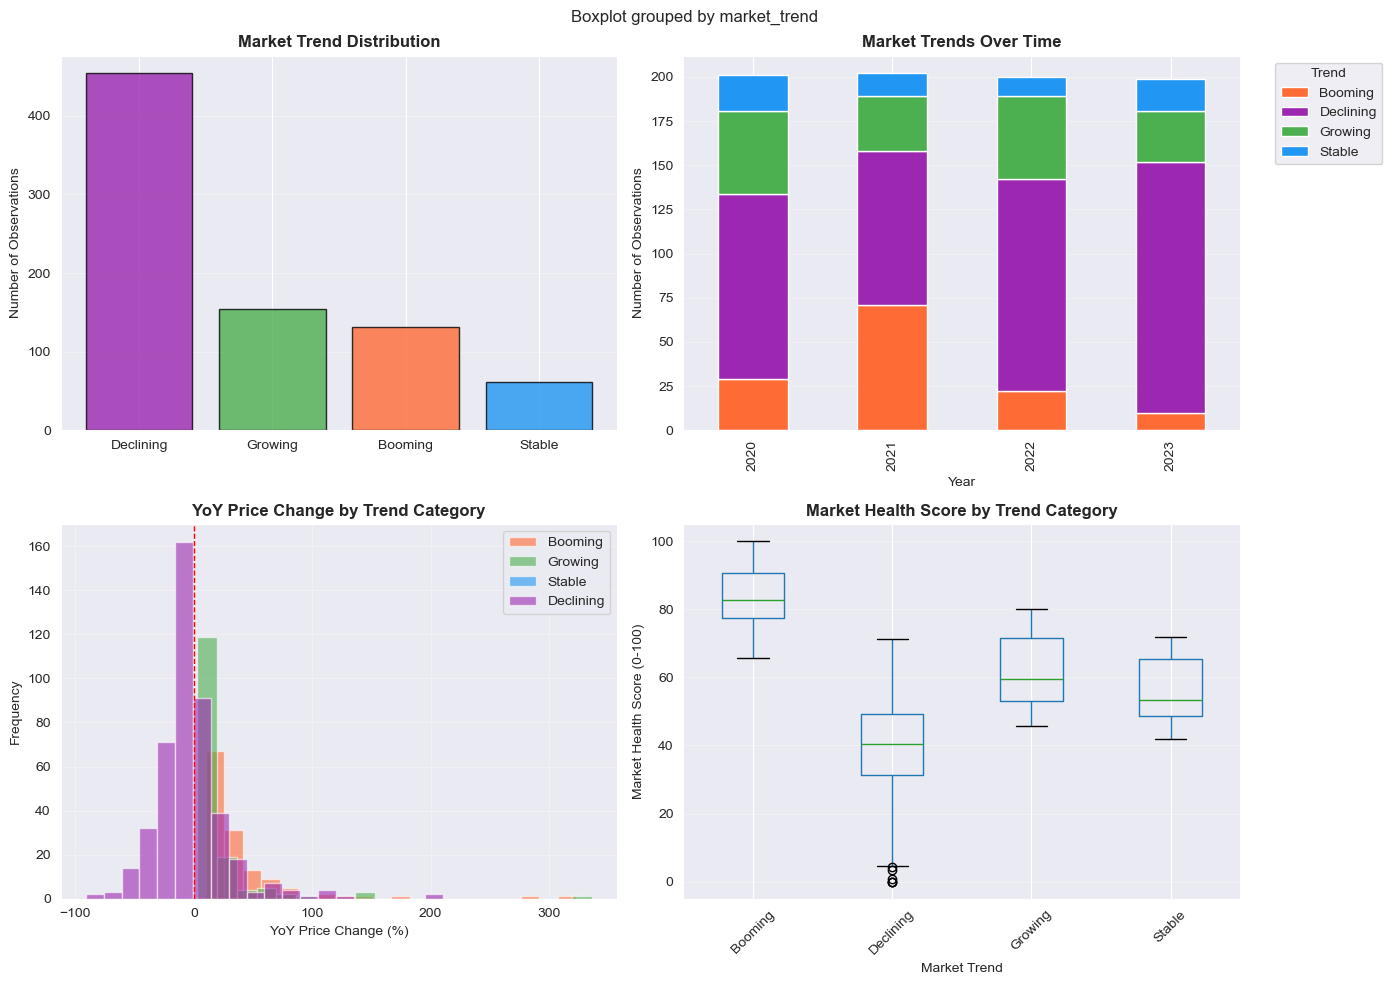

In [238]:
# Visualize classification distribution

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Distribution by trend
trend_counts = classified['market_trend'].value_counts()
colors = {'Booming': '#FF6B35', 'Growing': '#4CAF50', 'Stable': '#2196F3', 'Declining': '#9C27B0'}
trend_colors = [colors.get(t, 'gray') for t in trend_counts.index]

axes[0, 0].bar(trend_counts.index, trend_counts.values, color=trend_colors, edgecolor='black', alpha=0.8)
axes[0, 0].set_title('Market Trend Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Number of Observations')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot 2: Distribution by year
trend_by_year = classified.groupby(['year', 'market_trend']).size().unstack(fill_value=0)
trend_by_year.plot(kind='bar', stacked=True, ax=axes[0, 1], color=[colors.get(t, 'gray') for t in trend_by_year.columns])
axes[0, 1].set_title('Market Trends Over Time', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Number of Observations')
axes[0, 1].legend(title='Trend', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Price change distribution by trend
for trend in ['Booming', 'Growing', 'Stable', 'Declining']:
    trend_data = classified[classified['market_trend'] == trend]['yoy_price_change_pct']
    axes[1, 0].hist(trend_data, alpha=0.6, label=trend, bins=20, color=colors.get(trend, 'gray'))

axes[1, 0].set_title('YoY Price Change by Trend Category', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('YoY Price Change (%)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=1)

# Plot 4: Market health score by trend
classified.boxplot(column='market_health_score', by='market_trend', ax=axes[1, 1])
axes[1, 1].set_title('Market Health Score by Trend Category', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Market Trend')
axes[1, 1].set_ylabel('Market Health Score (0-100)')
axes[1, 1].grid(True, alpha=0.3, axis='y')
plt.sca(axes[1, 1])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 8. Final Dataset Preparation

**What we're doing:** Preparing the final ML-ready dataset.

**Why this matters:**
- Clean, structured data for model training
- All features validated and complete
- Target variable clearly defined

**Final Steps:**
1. Remove unclassified observations
2. Select relevant features for ML
3. Handle any remaining missing values
4. Validate data quality

**Output:** Dataset ready for train/test split and model training

---

In [239]:
# FINAL DATASET PREPARATION

# Use only classified observations
ml_data = classified.copy()

print(f"\n1. DATASET SIZE:")
print(f"Observations: {len(ml_data):,}")
print(f"Features: {ml_data.shape[1]}")

# 2. Select features for ML
print(f"\n2. FEATURE SELECTION:")

# Define feature groups
core_features = [
    'postcode_sector', 'year_quarter', 'year', 'quarter',
    'district', 'town_city', 'dominant_property_type'
]

price_features = [
    'median_price', 'mean_price', 'price_std',
    'yoy_price_change_pct', 'qoq_price_change_pct',
    'price_ma3', 'price_volatility', 'price_percentile'
]

volume_features = [
    'transaction_count', 'yoy_volume_change_pct',
    'qoq_volume_change_pct', 'volume_ma3',
    'relative_activity', 'activity_level'
]

derived_features = [
    'market_momentum', 'market_health_score',
    'trend_consistency'
]

target = ['market_trend']

all_features = core_features + price_features + volume_features + derived_features + target

# Keep only selected features
ml_data = ml_data[all_features].copy()

print(f"Core features: {len(core_features)}")
print(f"Price features: {len(price_features)}")
print(f"Volume features: {len(volume_features)}")
print(f"Derived features: {len(derived_features)}")
print(f"Target variable: {target}")
print(f"Total features: {len(all_features)}")

# 3. Handle missing values
print(f"\n3. MISSING VALUE CHECK:")

missing_summary = ml_data.isnull().sum()
missing_cols = missing_summary[missing_summary > 0]

if len(missing_cols) > 0:
    print(f"Columns with missing values:")
    for col, count in missing_cols.items():
        pct = count / len(ml_data) * 100
        print(f"{col}: {count} ({pct:.1f}%)")

    # Strategy: Fill numeric missing with median, categorical with mode
    for col in missing_cols.index:
        if ml_data[col].dtype in ['float64', 'int64']:
            ml_data[col] = ml_data[col].fillna(ml_data[col].median())
        else:
            ml_data[col] = ml_data[col].fillna(ml_data[col].mode()[0] if len(ml_data[col].mode()) > 0 else 'Unknown')

    print(f"Missing values filled")
else:
    print(f"No missing values!")

# 4. Data type validation
print(f"\n4. DATA TYPE VALIDATION:")
print(f"Numeric features: {ml_data.select_dtypes(include=[np.number]).shape[1]}")
print(f"Categorical features: {ml_data.select_dtypes(exclude=[np.number]).shape[1]}")

# 5. Target variable distribution
print(f"\n5. TARGET VARIABLE:")
target_dist = ml_data['market_trend'].value_counts()
print(f"Classes: {ml_data['market_trend'].nunique()}")
for trend, count in target_dist.items():
    pct = count / len(ml_data) * 100
    print(f"{trend}: {count:,} ({pct:.1f}%)")

# Check for class imbalance
min_class_size = target_dist.min()
max_class_size = target_dist.max()
imbalance_ratio = max_class_size / min_class_size

print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio > 3:
    print(f"Significant class imbalance detected")
    print(f"May need to address in model training (e.g., class weights)")
else:
    print(f"Reasonable class balance")


1. DATASET SIZE:
Observations: 802
Features: 30

2. FEATURE SELECTION:
Core features: 7
Price features: 8
Volume features: 6
Derived features: 3
Target variable: ['market_trend']
Total features: 25

3. MISSING VALUE CHECK:
Columns with missing values:
price_std: 26 (3.2%)
Missing values filled

4. DATA TYPE VALIDATION:
Numeric features: 17
Categorical features: 8

5. TARGET VARIABLE:
Classes: 4
Declining: 454 (56.6%)
Growing: 154 (19.2%)
Booming: 132 (16.5%)
Stable: 62 (7.7%)

Imbalance ratio: 7.32:1
Significant class imbalance detected
May need to address in model training (e.g., class weights)


## 9. Save ML-Ready Data

**What we're doing:** Saving the feature-engineered dataset for model training.

**Why this matters:**
- Preserves all feature engineering work
- Creates clean separation between data prep and modeling
- Enables reproducibility

**Output Files:**
1. **ML Dataset CSV:** Complete dataset with all features and labels
2. **Feature Metadata:** Documentation of all features created
3. **Statistics Summary:** Key statistics for reference

---

In [240]:
# SAVE ML-READY DATASET

# Define output paths
output_csv = '../data/final/ml_ready_dataset.csv'
output_metadata = '../data/final/feature_metadata.txt'

# Save main dataset
ml_data.to_csv(output_csv, index=False)
print(f"\nML-ready dataset saved:")
print(f"Size: {len(ml_data):,} rows × {ml_data.shape[1]} columns")

# Save feature metadata
with open(output_metadata, 'w') as f:
    f.write("FEATURE ENGINEERING METADATA\n")
    f.write("="*60 + "\n\n")
    f.write(f"Created: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Notebook: 03_feature_engineering.ipynb\n\n")

    f.write("DATASET SUMMARY:\n")
    f.write(f"Observations: {len(ml_data):,}\n")
    f.write(f"Features: {ml_data.shape[1]}\n")
    f.write(f"Postcode Sectors: {ml_data['postcode_sector'].nunique()}\n")
    f.write(f"Time Period: {ml_data['year'].min()}-{ml_data['year'].max()}\n\n")

    f.write("TARGET VARIABLE DISTRIBUTION:\n")
    for trend, count in ml_data['market_trend'].value_counts().items():
        pct = count / len(ml_data) * 100
        f.write(f"{trend}: {count:,} ({pct:.1f}%)\n")
    f.write("\n")

    f.write("FEATURE GROUPS:\n\n")
    f.write("Price Features:\n")
    for feat in price_features:
        f.write(f"- {feat}\n")
    f.write("\nVolume Features:\n")
    for feat in volume_features:
        f.write(f"- {feat}\n")
    f.write("\nDerived Features:\n")
    for feat in derived_features:
        f.write(f"- {feat}\n")

print(f"Feature metadata saved")



ML-ready dataset saved:
Size: 802 rows × 25 columns
Feature metadata saved


## 10. Summary & Key Insights

**Transformation Complete:**

From **67,000+ individual transactions** → To **~1,000 classified sector-quarter observations**

**Feature Engineering Achievements:**
- Created 20+ engineered features
- Calculated temporal trends (YoY, QoQ)
- Measured market activity levels
- Computed composite indicators
- Assigned classification labels

---

In [241]:
# ============================================
# FINAL SUMMARY
# ============================================

print("\n" + "="*60)
print("FEATURE ENGINEERING COMPLETE")
print("="*60)

print(f"\n📊 TRANSFORMATION SUMMARY:")
print(f"\nINPUT (Cleaned Transactions):")
print(f"  Transactions: {len(df):,}")
print(f"  Time span: {df['date_transfer'].min().date()} to {df['date_transfer'].max().date()}")

print(f"\nOUTPUT (ML-Ready Dataset):")
print(f"  Observations: {len(ml_data):,}")
print(f"  Features: {ml_data.shape[1]}")
print(f"  Sectors: {ml_data['postcode_sector'].nunique()}")
print(f"  Classification rate: 100%")

print(f"\n✅ FEATURES CREATED:")
print(f"  • Price trends: YoY change, QoQ change, moving averages")
print(f"  • Volume trends: YoY change, QoQ change, activity levels")
print(f"  • Market indicators: Momentum, health score, consistency")
print(f"  • Classification: 4 market trend categories")

print(f"\n🎯 CLASSIFICATION DISTRIBUTION:")
for trend, count in ml_data['market_trend'].value_counts().items():
    pct = count / len(ml_data) * 100
    emoji = {'Booming': '🚀', 'Growing': '📈', 'Stable': '📊', 'Declining': '📉'}.get(trend, '')
    print(f"  {emoji} {trend:12s}: {count:4,} ({pct:5.1f}%)")

print(f"\n📁 OUTPUT FILES:")
print(f"  • ML Dataset: ./data/final/ml_ready_dataset.csv")
print(f"  • Metadata: ./data/final/feature_metadata.txt")

print(f"\n📝 NEXT NOTEBOOK: 04_model_training.ipynb")
print(f"  Tasks:")
print(f"    • Train/test split")
print(f"    • Model selection and training")
print(f"    • Hyperparameter tuning")
print(f"    • Model evaluation")
print(f"    • Feature importance analysis")

print("\n" + "="*60)
print("✓ READY FOR MODEL TRAINING!")
print("="*60)



FEATURE ENGINEERING COMPLETE

📊 TRANSFORMATION SUMMARY:

INPUT (Cleaned Transactions):
  Transactions: 66,406
  Time span: 2019-01-02 to 2023-12-31

OUTPUT (ML-Ready Dataset):
  Observations: 802
  Features: 25
  Sectors: 52
  Classification rate: 100%

✅ FEATURES CREATED:
  • Price trends: YoY change, QoQ change, moving averages
  • Volume trends: YoY change, QoQ change, activity levels
  • Market indicators: Momentum, health score, consistency
  • Classification: 4 market trend categories

🎯 CLASSIFICATION DISTRIBUTION:
  📉 Declining   :  454 ( 56.6%)
  📈 Growing     :  154 ( 19.2%)
  🚀 Booming     :  132 ( 16.5%)
  📊 Stable      :   62 (  7.7%)

📁 OUTPUT FILES:
  • ML Dataset: ./data/final/ml_ready_dataset.csv
  • Metadata: ./data/final/feature_metadata.txt

📝 NEXT NOTEBOOK: 04_model_training.ipynb
  Tasks:
    • Train/test split
    • Model selection and training
    • Hyperparameter tuning
    • Model evaluation
    • Feature importance analysis

✓ READY FOR MODEL TRAINING!
